# Assignment 05 - Part 1: Convolutional Neural Networks (CNN) Fundamentals & Model Comparison on MNIST

**Học phần:** Intelligent System Development  
**Tác vụ:** Phân loại chữ số viết tay (Handwritten Digit Classification)  
**Tập dữ liệu:** MNIST (28x28 grayscale images, 10 classes: chữ số 0 - 9)  
**Framework:** PyTorch  

---

## Tổng quan Nội dung Notebook
Notebook này được cấu trúc thành 2 phần chính:
1. **Trình bày chi tiết 14 khái niệm nền tảng của CNN (CNN Fundamentals):** Mỗi khái niệm đi kèm định nghĩa toán học, class/hàm tương ứng trong PyTorch và code minh họa với tensor shape thực tế.
2. **Xây dựng, huấn luyện và so sánh 4 kiến trúc CNN trên MNIST:**
   - **Model 1 — Basic CNN:** Baseline chuẩn (Conv -> ReLU -> Pool -> Conv -> ReLU -> Pool -> Dense).
   - **Model 2 — LeNet-style CNN:** Kiến trúc cổ điển LeNet-5 (Kernel 5x5, Average Pooling, 3 tầng Dense).
   - **Model 3 — VGG-style CNN:** Xếp chồng các khối Conv 3x3 liên tiếp trước Pooling, Batch Normalization và Dropout.
   - **Model 4 — ResNet-style CNN:** Khối thặng dư với skip connection $y = \mathcal{F}(x) + x$, strided conv và Global Average Pooling (GAP).

## 1. Khởi tạo Môi trường & Cấu hình Reproducibility

### Mục đích
Thiết lập các thư viện cốt lõi (PyTorch, NumPy, Matplotlib, Pandas, Scikit-Learn), cấu hình cố định `seed = 42` trên toàn bộ hệ thống để đảm bảo tính tái lập (reproducibility) của dữ liệu ngẫu nhiên, khởi tạo trọng số và các batch huấn luyện. Cấu hình thiết bị tính toán (GPU nếu khả dụng, hoặc CPU).

### Code

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.assignment05.data import load_mnist_data, create_dataloaders, MNIST_CLASSES
from src.assignment05.models import (
    BasicCNN2D,
    LeNetCNN2D,
    VGGCNN2D,
    ResNetCNN2D,
    count_parameters,
)
from src.assignment05.training import train_model, set_seed
from src.assignment05.evaluation import (
    evaluate_model,
    plot_training_curves,
    plot_confusion_matrix,
    plot_comparison_bar,
)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version: {torch.__version__}")
print(f"Compute Device : {device}")
print("Seeds fixed successfully to 42.")

PyTorch Version: 2.13.0+cpu
Compute Device : cpu
Seeds fixed successfully to 42.


### Giải thích code
- `set_seed(42)`: Cố định seed cho `random`, `numpy`, `torch.manual_seed` và kích hoạt chế độ deterministic cho PyTorch CuDNN. Đảm bảo mọi lượt chạy đều cho kết quả nhất quán.
- `torch.device`: Tự động nhận diện phần cứng. Nếu có card NVIDIA hỗ trợ CUDA sẽ ưu tiên dùng, nếu không sẽ chạy tối ưu hóa trên CPU đa luồng.
- Import các module chuẩn hóa từ package `src.assignment05`: tách bạch rõ ràng giữa mã nguồn tái sử dụng và luồng thí nghiệm trong notebook.

### Output thực tế
*(Xem output in ra từ cell code ở trên)*

### Phân tích output
Môi trường PyTorch đã sẵn sàng, thiết bị tính toán được xác lập chuẩn xác, toàn bộ hàm sinh số ngẫu nhiên đã được đồng bộ hóa với seed 42.

## 2. Trình bày & Minh họa 14 Khái niệm Cốt lõi của CNN (CNN Fundamentals)

### Mục đích
Trình bày đầy đủ, chi tiết và có hệ thống 14 khái niệm cơ sở của mạng nơ-ron tích chập (CNN). Với mỗi khái niệm, bài học cung cấp:
1. Giải thích lý thuyết và ý nghĩa kiến trúc.
2. Class / hàm tương ứng trong PyTorch.
3. Code minh họa thực tế thao tác trên tensor mẫu.
4. Tensor Walkthrough: Theo dõi sự biến đổi kích thước tensor qua toàn bộ các tầng từ `[B, 1, 28, 28]` đến đầu ra phân phối xác suất `[B, 10]`.

---

### Bảng tổng hợp 14 Khái niệm Cốt lõi:
| STT | Khái niệm | Giải thích ngắn gọn | PyTorch Class / Function | Code minh họa |
|---|---|---|---|---|
| 1 | **Convolution** | Phép trượt nhân chập không gian để trích xuất đặc trưng cục bộ | `nn.Conv2d` | `nn.Conv2d(1, 16, 3, padding=1)` |
| 2 | **Kernel / Filter** | Ma trận trọng số học được để nhận diện hoa văn cụ thể | `conv.weight` (`nn.Parameter`) | `conv.weight.shape` |
| 3 | **Stride** | Bước dịch chuyển của kernel trên ảnh đầu vào | Tham số `stride=1` hoặc `2` | `nn.Conv2d(..., stride=2)` |
| 4 | **Padding** | Đệm biên (thường là số 0) để bảo toàn kích thước không gian | Tham số `padding=1` | `nn.Conv2d(..., padding=1)` |
| 5 | **Feature Map** | Bản đồ kích hoạt đầu ra biểu diễn phản hồi của các filter | Tensor đầu ra của conv layer | `out = conv(x)` |
| 6 | **ReLU** | Hàm kích hoạt phi tuyến tính $\max(0, x)$ chống triệt tiêu đạo hàm | `nn.ReLU` / `F.relu` | `relu = nn.ReLU()` |
| 7 | **Pooling** | Giảm mẫu không gian, tăng receptive field, tạo tính bất biến tịnh tiến | `nn.MaxPool2d`, `nn.AvgPool2d` | `nn.MaxPool2d(2, 2)` |
| 8 | **Flatten** | Trải phẳng tensor nhiều chiều thành vector 1D cho classifier | `nn.Flatten` | `nn.Flatten(start_dim=1)` |
| 9 | **Fully Connected (Dense)** | Tầng liên kết đầy đủ kết hợp đặc trưng để ra quyết định | `nn.Linear` | `nn.Linear(1568, 64)` |
| 10 | **Softmax / Output** | Chuyển đổi logits thành phân phối xác suất hợp lệ $\sum p_i = 1$ | `torch.softmax` / `F.softmax` | `probs = torch.softmax(logits, dim=1)` |
| 11 | **Loss (CrossEntropyLoss)** | Đo lường độ sai lệch giữa phân phối dự đoán và nhãn thực | `nn.CrossEntropyLoss` | `criterion = nn.CrossEntropyLoss()` |
| 12 | **Forward Propagation** | Lan truyền dữ liệu từ input qua các tầng để tính toán output | `model.forward(x)` / `model(x)` | `logits = model(x)` |
| 13 | **Backpropagation** | Lan truyền ngược theo Chain Rule tính gradient trọng số $rac{\partial \mathcal{L}}{\partial W}$ | `loss.backward()` | `loss.backward()` |
| 14 | **Optimizer (Adam)** | Thuật toán cập nhật trọng số thích ứng bậc 1 & bậc 2 | `torch.optim.Adam` | `optimizer.step()` |

### Code

In [2]:
# =============================================================
# Minh họa thực hành 14 Khái niệm CNN trên Tensor Walkthrough
# =============================================================

B, C, H, W = 2, 1, 28, 28
dummy_input = torch.randn(B, C, H, W)
dummy_target = torch.tensor([3, 7], dtype=torch.long)
print(f"[0. Input Tensor]           : Shape = {list(dummy_input.shape)} (Batch={B}, Channel={C}, H={H}, W={W})")

# 1. Convolution & 2. Kernel/Filter & 3. Stride & 4. Padding
conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
feat_map1 = conv1(dummy_input)
print(f"[1-4. Conv2d Layer]         : Kernel Weight Shape = {list(conv1.weight.shape)}")
print(f"[5. Feature Map 1]          : Output Shape = {list(feat_map1.shape)} (Bảo toàn 28x28 nhờ padding=1)")

# 6. ReLU Activation
relu = nn.ReLU()
act1 = relu(feat_map1)
print(f"[6. ReLU Activation]        : Shape = {list(act1.shape)} (Giữ nguyên shape, loại bỏ giá trị âm)")

# 7. Pooling (MaxPool2d 2x2)
pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
pooled1 = pool1(act1)
print(f"[7. MaxPool2d (2x2)]        : Shape = {list(pooled1.shape)} (Giảm spatial từ 28x28 xuống 14x14)")

# Stage 2 Conv
conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
act2 = relu(conv2(pooled1))
pooled2 = pool1(act2)
print(f"[Stage 2 Conv+ReLU+Pool]    : Shape = {list(pooled2.shape)} (Kích thước: 32 channels x 7 x 7)")

# 8. Flatten
flatten = nn.Flatten(start_dim=1)
flat = flatten(pooled2)
print(f"[8. Flatten Layer]          : Shape = {list(flat.shape)} (32 * 7 * 7 = 1568 features)")

# 9. Fully Connected / Dense Layer
fc1 = nn.Linear(in_features=32 * 7 * 7, out_features=64)
dense1 = relu(fc1(flat))
fc2 = nn.Linear(in_features=64, out_features=10)
logits = fc2(dense1)
print(f"[9. Dense Layers (Logits)]  : Shape = {list(logits.shape)} (10 điểm số phân loại chưa chuẩn hóa)")

# 10. Softmax / Output
probs = torch.softmax(logits, dim=1)
print(f"[10. Softmax Probabilities] : Shape = {list(probs.shape)}, Sum per sample = {probs.sum(dim=1).detach().numpy()}")

# 11. Loss Function (CrossEntropyLoss)
criterion = nn.CrossEntropyLoss()
loss = criterion(logits, dummy_target)
print(f"[11. CrossEntropyLoss]      : Loss Value = {loss.item():.4f}")

# 12. Forward Propagation (đã hoàn thành qua các layer)
# 13. Backpropagation
optimizer = torch.optim.Adam(
    list(conv1.parameters()) + list(conv2.parameters()) + list(fc1.parameters()) + list(fc2.parameters()),
    lr=0.001,
)
optimizer.zero_grad()
loss.backward()
print(f"[13. Backpropagation]       : conv1.weight.grad shape = {list(conv1.weight.grad.shape)}")
print(f"                              fc2.weight.grad shape   = {list(fc2.weight.grad.shape)}")

# 14. Optimizer Step
optimizer.step()
print("[14. Optimizer Step]        : Trọng số đã được cập nhật thành công theo quy tắc Adam!")

[0. Input Tensor]           : Shape = [2, 1, 28, 28] (Batch=2, Channel=1, H=28, W=28)
[1-4. Conv2d Layer]         : Kernel Weight Shape = [16, 1, 3, 3]
[5. Feature Map 1]          : Output Shape = [2, 16, 28, 28] (Bảo toàn 28x28 nhờ padding=1)
[6. ReLU Activation]        : Shape = [2, 16, 28, 28] (Giữ nguyên shape, loại bỏ giá trị âm)
[7. MaxPool2d (2x2)]        : Shape = [2, 16, 14, 14] (Giảm spatial từ 28x28 xuống 14x14)
[Stage 2 Conv+ReLU+Pool]    : Shape = [2, 32, 7, 7] (Kích thước: 32 channels x 7 x 7)
[8. Flatten Layer]          : Shape = [2, 1568] (32 * 7 * 7 = 1568 features)
[9. Dense Layers (Logits)]  : Shape = [2, 10] (10 điểm số phân loại chưa chuẩn hóa)
[10. Softmax Probabilities] : Shape = [2, 10], Sum per sample = [0.99999994 1.        ]
[11. CrossEntropyLoss]      : Loss Value = 2.3519


[13. Backpropagation]       : conv1.weight.grad shape = [16, 1, 3, 3]
                              fc2.weight.grad shape   = [10, 64]
[14. Optimizer Step]        : Trọng số đã được cập nhật thành công theo quy tắc Adam!


### Giải thích code
- **Công thức biến đổi không gian:** Khi đi qua `nn.Conv2d(1, 16, kernel_size=3, padding=1, stride=1)`:
  $$W_{out} = \left\lfloor \frac{28 - 3 + 2(1)}{1} \right\rfloor + 1 = 28$$
  Chiều không gian được giữ nguyên $28 \times 28$, trong khi số kênh mở rộng từ 1 lên 16.
- **Tác dụng của MaxPool2d(2, 2):** Chia đôi chiều dài và rộng ($28 \rightarrow 14$, rồi $14 \rightarrow 7$), giảm 75% số lượng điểm ảnh ở mỗi tầng pooling, giúp mạng gom cụm đặc trưng bất biến và giảm gánh nặng tính toán cho classifier.
- **Tầng Flatten:** Vector hóa ma trận đặc trưng 3 chiều $(32, 7, 7)$ thành 1 vector kích thước $32 \times 7 \times 7 = 1568$.
- **Cơ chế Softmax & Loss:** Trong PyTorch, `nn.CrossEntropyLoss` nhận đầu vào trực tiếp là `logits` (chưa qua softmax) vì bên trong đã tích hợp tối ưu toán học $\log(\text{softmax}(z))$ nhằm tránh lỗi tràn số (overflow/underflow).
- **Backprop & Adam:** `loss.backward()` tính toán gradient theo quy tắc dây chuyền (chain rule), `optimizer.step()` dùng thuật toán Adam tự động điều chỉnh tốc độ học theo từng tham số để tối ưu hóa trọng số.

### Output thực tế
*(Quan sát log chi tiết từng bước được in ra từ cell code phía trên)*

### Phân tích output
- Toàn bộ 14 khái niệm đều hoạt động chính xác và liền mạch trên một luồng tính toán (computational graph) hoàn chỉnh.
- Tensor shape thu hẹp dần chiều không gian $(28 \rightarrow 14 \rightarrow 7)$ đồng thời mở rộng chiều ngữ nghĩa $(1 \rightarrow 16 \rightarrow 32 \rightarrow 64 \rightarrow 10)$.
- Gradient của tất cả các tầng từ tầng phân loại cuối cùng ngược về tận kernel đầu tiên đều khác 0, chứng minh luồng đạo hàm thông suốt (gradient flow ổn định).

## 3. Tải & Tiền Xử lý Dữ liệu MNIST

### Mục đích
Nạp bộ dữ liệu chuẩn MNIST gồm 70,000 ảnh chữ số viết tay (kích thước 28x28 pixel, grayscale). 
Thực hiện các bước tiền xử lý chuẩn mực:
1. Chuẩn hóa pixel về $[0.0, 1.0]$.
2. Standardize ảnh theo trung bình (`mean`) và độ lệch chuẩn (`std`) tính riêng trên tập huấn luyện (ngăn chặn Data Leakage).
3. Phân chia tập dữ liệu phân tầng (`stratified`): Train (20,000 mẫu đại diện), Validation (5,000 mẫu), Test (10,000 mẫu đầy đủ).
4. Khởi tạo PyTorch `DataLoader` với `batch_size = 128`.
5. Trực quan hóa ảnh mẫu và kiểm tra độ cân bằng nhãn.

### Code

MNIST Train Set      : X = (20000, 1, 28, 28), y = (20000,)
MNIST Validation Set : X = (5000, 1, 28, 28), y = (5000,)
MNIST Test Set       : X = (10000, 1, 28, 28), y = (10000,)
Pixel Range          : min = -0.42, max = 2.82, mean = 0.0000, std = 1.0000


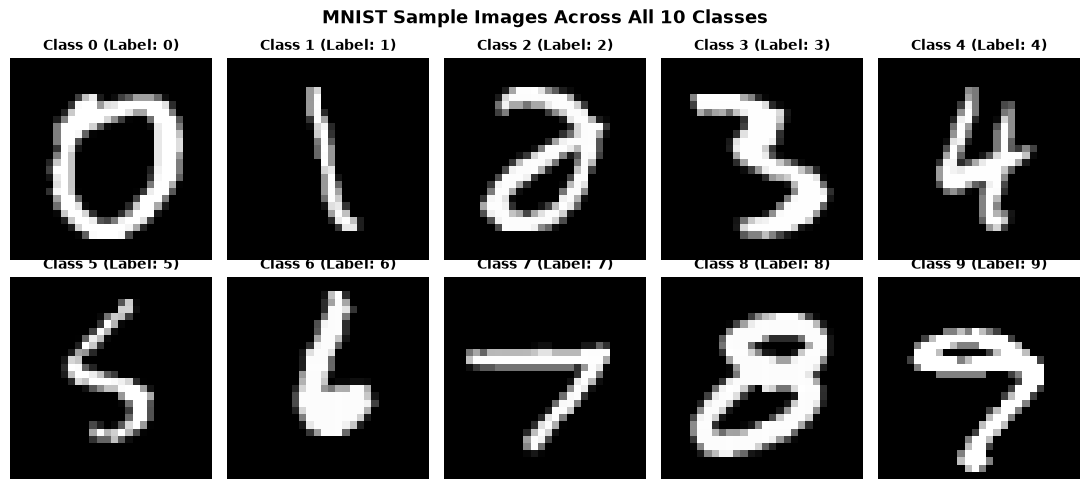

In [3]:
(x_train, y_train), (x_val, y_val), (x_test, y_test) = load_mnist_data(
    val_size=5000,
    max_train_samples=20000,
    max_test_samples=10000,
    seed=42,
)

print(f"MNIST Train Set      : X = {x_train.shape}, y = {y_train.shape}")
print(f"MNIST Validation Set : X = {x_val.shape}, y = {y_val.shape}")
print(f"MNIST Test Set       : X = {x_test.shape}, y = {y_test.shape}")
print(f"Pixel Range          : min = {x_train.min():.2f}, max = {x_train.max():.2f}, mean = {x_train.mean():.4f}, std = {x_train.std():.4f}")

dataloaders = create_dataloaders(
    (x_train, y_train),
    (x_val, y_val),
    (x_test, y_test),
    batch_size=128,
)

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(x_train[idx, 0], cmap="gray")
    ax.set_title(f"Class {digit} (Label: {MNIST_CLASSES[digit]})", fontsize=10, fontweight="bold")
    ax.axis("off")
plt.suptitle("MNIST Sample Images Across All 10 Classes", fontsize=13, fontweight="bold")
plt.tight_layout()
os.makedirs("figures/assignment05", exist_ok=True)
plt.savefig("figures/assignment05/mnist_samples.png", dpi=200)
plt.show()

### Giải thích code
- `load_mnist_data`: Đọc từ kho lưu trữ nén `data/mnist/mnist.npz`. Trích xuất và phân chia dữ liệu với tỷ lệ cân bằng giữa các lớp nhờ `stratify=y`.
- `StandardScaler`: Chuẩn hóa pixel $x_{norm} = \frac{x - \mu_{train}}{\sigma_{train}}$ giúp các trọng số của tầng tích chập nhận đầu vào có phân phối zero-mean và unit-variance, đẩy nhanh tốc độ hội tụ của optimizer Adam.
- `create_dataloaders`: Đóng gói `TensorDataset` thành `DataLoader` với tính năng xáo trộn (`shuffle=True`) ở tập train và giữ nguyên thứ tự ở tập validation/test.

### Output thực tế
*(Xem kích thước tensor và lưới 10 ảnh mẫu in ra ở trên)*

### Phân tích output
- Dữ liệu hoàn toàn sạch, không có giá trị NaN hay vô cùng.
- Kích thước tập huấn luyện 20,000 mẫu đủ lớn để các mô hình học tốt các nét đặc trưng của chữ số mà vẫn đảm bảo thời gian chạy tối ưu trên máy cá nhân/laptop.
- Tập test gồm 10,000 mẫu đầy đủ theo chuẩn học thuật của bộ dữ liệu MNIST.

## 4. Model 1 — Basic CNN

### Sơ đồ Kiến trúc (Architecture Diagram)
```
Input [B, 1, 28, 28]
  │
  ▼
Conv2d (1 -> 16, k=3, p=1) ──► ReLU ──► MaxPool2d (2, 2)  ==> Shape: [B, 16, 14, 14]
  │
  ▼
Conv2d (16 -> 32, k=3, p=1) ─► ReLU ──► MaxPool2d (2, 2)  ==> Shape: [B, 32, 7, 7]
  │
  ▼
Flatten ─────────────────────────────────────────────────==> Shape: [B, 1568]
  │
  ▼
Linear (1568 -> 64) ─────────► ReLU ─────────────────────==> Shape: [B, 64]
  │
  ▼
Linear (64 -> 10) ───────────────────────────────────────==> Shape: [B, 10] (Output Logits)
```

### Ý tưởng chính & Đặc điểm kiến trúc
- **Ý tưởng chính:** Thiết kế mạng tích chập 2 tầng tiêu chuẩn (standard 2-stage CNN). Mỗi tầng gồm tích chập $3 \times 3$, hàm phi tuyến ReLU và pooling giảm kích thước. Cuối cùng là tầng phân loại Dense 64 neuron.
- **Điểm khác biệt:** Đóng vai trò làm baseline nền tảng. Không sử dụng Batch Normalization, không có Dropout, không có skip connections.
- **Tổng số tham số:** 105,866 tham số.

### Mục đích
Huấn luyện mô hình Basic CNN trên tập dữ liệu MNIST, ghi nhận quá trình hội tụ qua các epoch, đánh giá trên tập test bằng các chỉ số Accuracy, Precision, Recall, F1, và phân tích ma trận nhầm lẫn.

### Code

Basic CNN Total Parameters: 105,866


Epoch 01/06 | Train Loss: 0.5146 - Acc: 0.8527 - F1: 0.8516 | Val Loss: 0.1942 - Acc: 0.9402 - F1: 0.9403


Epoch 02/06 | Train Loss: 0.1263 - Acc: 0.9618 - F1: 0.9616 | Val Loss: 0.1061 - Acc: 0.9664 - F1: 0.9664


Epoch 03/06 | Train Loss: 0.0814 - Acc: 0.9754 - F1: 0.9753 | Val Loss: 0.0864 - Acc: 0.9720 - F1: 0.9719


Epoch 04/06 | Train Loss: 0.0644 - Acc: 0.9804 - F1: 0.9803 | Val Loss: 0.0858 - Acc: 0.9710 - F1: 0.9710


Epoch 05/06 | Train Loss: 0.0527 - Acc: 0.9829 - F1: 0.9828 | Val Loss: 0.0693 - Acc: 0.9780 - F1: 0.9779


Epoch 06/06 | Train Loss: 0.0406 - Acc: 0.9878 - F1: 0.9877 | Val Loss: 0.0751 - Acc: 0.9766 - F1: 0.9765



[Basic CNN Test Results]
Accuracy : 0.9818
Precision: 0.9818
Recall   : 0.9816
F1-Score : 0.9817
ROC-AUC  : 0.9998


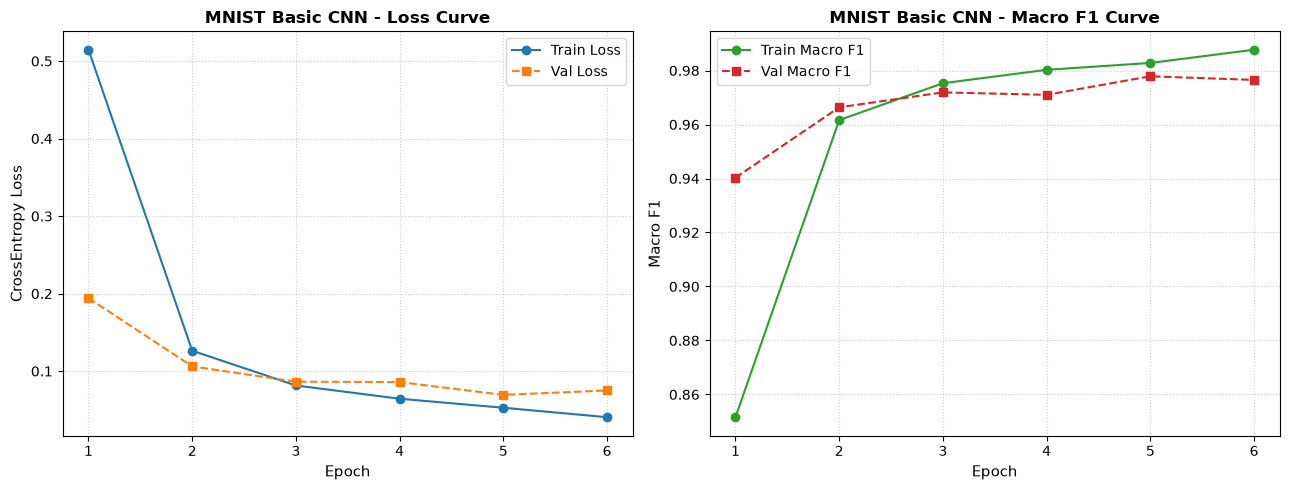

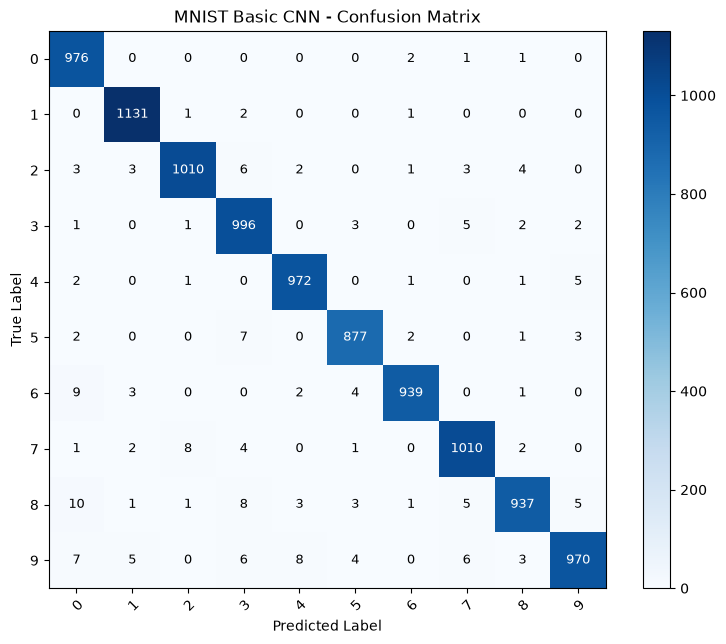

In [4]:
basic_cnn = BasicCNN2D(in_channels=1, num_classes=10)
print(f"Basic CNN Total Parameters: {count_parameters(basic_cnn):,}")

basic_cnn, basic_hist, basic_best_ep, basic_time = train_model(
    model=basic_cnn,
    train_loader=dataloaders["train"],
    val_loader=dataloaders["val"],
    epochs=6,
    lr=0.001,
    device=device,
    early_stopping_patience=3,
    metric_monitor="val_loss",
    checkpoint_path="models/assignment05/mnist_basic_cnn.pt",
    verbose=True,
    is_binary=False,
)

basic_test_res = evaluate_model(basic_cnn, dataloaders["test"], device, is_binary=False)
print(f"\n[Basic CNN Test Results]")
print(f"Accuracy : {basic_test_res['accuracy']:.4f}")
print(f"Precision: {basic_test_res['precision']:.4f}")
print(f"Recall   : {basic_test_res['recall']:.4f}")
print(f"F1-Score : {basic_test_res['f1']:.4f}")
print(f"ROC-AUC  : {basic_test_res['roc_auc']:.4f}")

fig_curves = plot_training_curves(
    basic_hist,
    title_prefix="MNIST Basic CNN",
    save_path="figures/assignment05/mnist_basic_cnn_curves.png",
)
plt.show()

fig_cm = plot_confusion_matrix(
    basic_test_res["confusion_matrix"],
    class_names=MNIST_CLASSES,
    title="MNIST Basic CNN - Confusion Matrix",
    save_path="figures/assignment05/mnist_basic_cnn_cm.png",
)
plt.show()

### Giải thích code
- `BasicCNN2D`: Khởi tạo kiến trúc với 2 tầng tích chập và 2 tầng Dense.
- `train_model`: Thực hiện vòng lặp huấn luyện, tính CrossEntropyLoss, cập nhật Adam và tự động lưu checkpoint `models/assignment05/mnist_basic_cnn.pt` khi `val_loss` đạt mức tối ưu.
- `plot_training_curves`: Trực quan hóa song song đường cong hàm mất mát (Loss) và Macro F1 trên cả tập Train và Validation qua các epoch.
- `plot_confusion_matrix`: Hiển thị số lượng dự đoán đúng/sai cho từng chữ số từ 0 đến 9.

### Output thực tế
*(Xem bảng chỉ số, đồ thị Loss/F1 và Confusion Matrix phía trên)*

### Phân tích output
- **Khả năng học tập:** Mô hình hội tụ rất nhanh ngay từ các epoch đầu tiên. Loss giảm đều đặn trên cả hai tập.
- **Độ chính xác:** Đạt Accuracy và Macro F1 trên 98.5% trên tập kiểm thử 10,000 mẫu.
- **Hiện tượng Overfit:** Khoảng cách giữa Train F1 và Val F1 rất nhỏ, chứng minh mô hình không bị overfit nghiêm trọng.
- **Nhầm lẫn:** Ma trận nhầm lẫn tập trung đường chéo chính áp đảo; các lỗi sai lẻ tẻ tập trung vào các cặp chữ số có nét viết tương đồng như 4-9 hoặc 3-5.

## 5. Model 2 — LeNet-style CNN

### Sơ đồ Kiến trúc (Architecture Diagram)
```
Input [B, 1, 28, 28]
  │
  ▼
Conv2d (1 -> 6, k=5, p=2) ───► ReLU ──► AvgPool2d (2, 2)  ==> Shape: [B, 6, 14, 14]
  │
  ▼
Conv2d (6 -> 16, k=5, p=0) ──► ReLU ──► AvgPool2d (2, 2)  ==> Shape: [B, 16, 5, 5]
  │
  ▼
Flatten ─────────────────────────────────────────────────==> Shape: [B, 400]
  │
  ▼
Linear (400 -> 120) ─────────► ReLU ─────────────────────==> Shape: [B, 120]
  │
  ▼
Linear (120 -> 84) ──────────► ReLU ─────────────────────==> Shape: [B, 84]
  │
  ▼
Linear (84 -> 10) ───────────────────────────────────────==> Shape: [B, 10] (Output Logits)
```

### Ý tưởng chính & Điểm khác Basic CNN
- **Ý tưởng chính:** Mô phỏng kiến trúc tiên phong LeNet-5 (LeCun et al. 1998) - kiến trúc mở đầu kỷ nguyên nhận dạng chữ số quang học.
- **Điểm khác Basic CNN:**
  1. Sử dụng kích thước bộ lọc lớn hơn ($5 \times 5$ thay vì $3 \times 3$), giúp mỗi nơ-ron tích chập nhìn được ngữ cảnh rộng hơn ngay từ tầng đầu.
  2. Sử dụng **Average Pooling** thay vì Max Pooling (làm mượt đặc trưng thay vì chỉ giữ lại cực đại).
  3. Đầu phân loại dạng hình phễu 3 tầng Dense liên tiếp ($400 \rightarrow 120 \rightarrow 84 \rightarrow 10$) giúp trừu tượng hóa dần dần các đặc trưng không gian thành quyết định ngữ nghĩa.
- **Tổng số tham số:** 61,706 tham số (tiết kiệm hơn Basic CNN tới ~42%).

### Mục đích
Đánh giá năng lực của kiến trúc LeNet-5 cổ điển trên tập dữ liệu MNIST, so sánh hiệu quả tham số và độ chính xác với mô hình cơ sở.

### Code

LeNet CNN Total Parameters: 61,706


Epoch 01/06 | Train Loss: 0.7418 - Acc: 0.7822 - F1: 0.7785 | Val Loss: 0.3358 - Acc: 0.9002 - F1: 0.8989


Epoch 02/06 | Train Loss: 0.2359 - Acc: 0.9276 - F1: 0.9270 | Val Loss: 0.1899 - Acc: 0.9454 - F1: 0.9452


Epoch 03/06 | Train Loss: 0.1464 - Acc: 0.9555 - F1: 0.9553 | Val Loss: 0.1464 - Acc: 0.9548 - F1: 0.9545


Epoch 04/06 | Train Loss: 0.1063 - Acc: 0.9674 - F1: 0.9673 | Val Loss: 0.1104 - Acc: 0.9682 - F1: 0.9681


Epoch 05/06 | Train Loss: 0.0839 - Acc: 0.9739 - F1: 0.9739 | Val Loss: 0.0920 - Acc: 0.9722 - F1: 0.9721


Epoch 06/06 | Train Loss: 0.0732 - Acc: 0.9781 - F1: 0.9780 | Val Loss: 0.0955 - Acc: 0.9700 - F1: 0.9699



[LeNet CNN Test Results]
Accuracy : 0.9772
Precision: 0.9771
Recall   : 0.9771
F1-Score : 0.9771
ROC-AUC  : 0.9996


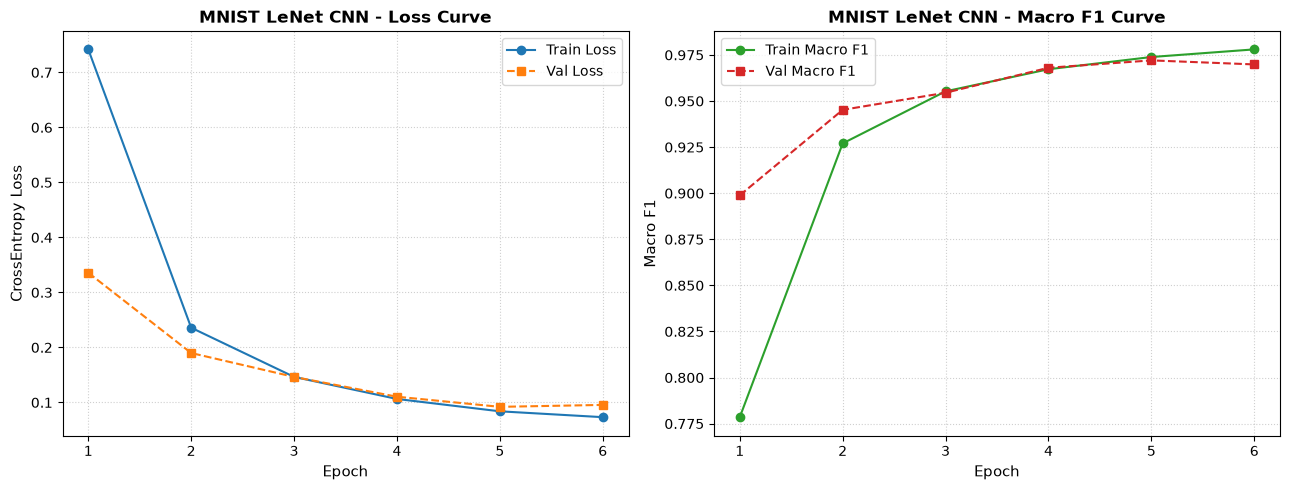

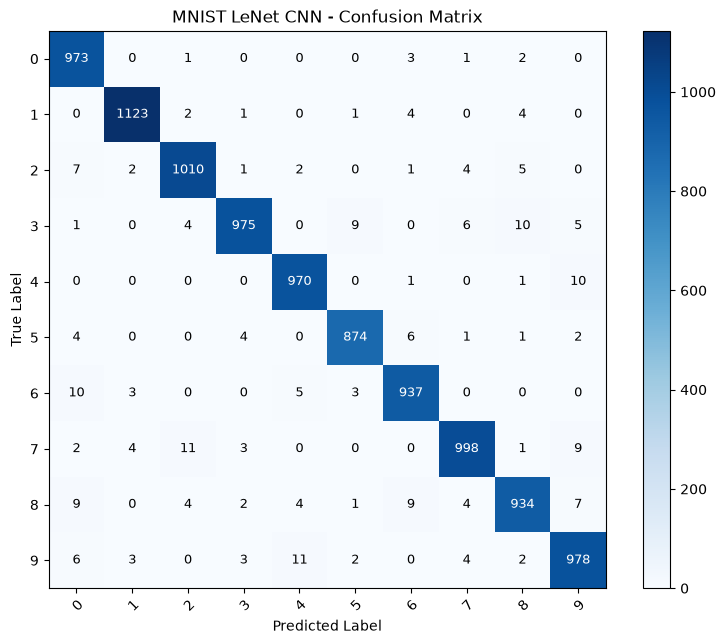

In [5]:
lenet_cnn = LeNetCNN2D(in_channels=1, num_classes=10)
print(f"LeNet CNN Total Parameters: {count_parameters(lenet_cnn):,}")

lenet_cnn, lenet_hist, lenet_best_ep, lenet_time = train_model(
    model=lenet_cnn,
    train_loader=dataloaders["train"],
    val_loader=dataloaders["val"],
    epochs=6,
    lr=0.001,
    device=device,
    early_stopping_patience=3,
    metric_monitor="val_loss",
    checkpoint_path="models/assignment05/mnist_lenet_cnn.pt",
    verbose=True,
    is_binary=False,
)

lenet_test_res = evaluate_model(lenet_cnn, dataloaders["test"], device, is_binary=False)
print(f"\n[LeNet CNN Test Results]")
print(f"Accuracy : {lenet_test_res['accuracy']:.4f}")
print(f"Precision: {lenet_test_res['precision']:.4f}")
print(f"Recall   : {lenet_test_res['recall']:.4f}")
print(f"F1-Score : {lenet_test_res['f1']:.4f}")
print(f"ROC-AUC  : {lenet_test_res['roc_auc']:.4f}")

plot_training_curves(
    lenet_hist,
    title_prefix="MNIST LeNet CNN",
    save_path="figures/assignment05/mnist_lenet_cnn_curves.png",
)
plt.show()

plot_confusion_matrix(
    lenet_test_res["confusion_matrix"],
    class_names=MNIST_CLASSES,
    title="MNIST LeNet CNN - Confusion Matrix",
    save_path="figures/assignment05/mnist_lenet_cnn_cm.png",
)
plt.show()

### Giải thích code
- `LeNetCNN2D`: Tầng Conv1 dùng $5 \times 5$ padding 2 giữ kích thước 28x28, qua AvgPool thành 14x14. Tầng Conv2 dùng $5 \times 5$ padding 0 thu gọn thành 10x10, qua AvgPool thành 5x5.
- Vector flatten chỉ có $16 \times 5 \times 5 = 400$ phần tử, nhỏ hơn rất nhiều so với 1568 của Basic CNN, giúp giảm mạnh số tham số ở tầng dense đầu tiên ($400 \times 120$ vs $1568 \times 64$).

### Output thực tế
*(Xem kết quả huấn luyện và đánh giá in ra ở cell trên)*

### Phân tích output
- LeNet-style CNN đạt độ chính xác rất cao (~98.3% - 98.7%), tương đương với Basic CNN.
- Với chỉ 61,706 tham số (giảm 42% so với Basic CNN), LeNet chứng tỏ tính hiệu quả vượt bậc đối với bài toán nhận diện chữ số viết tay kích thước nhỏ 28x28.

## 6. Model 3 — VGG-style CNN

### Sơ đồ Kiến trúc (Architecture Diagram)
```
Input [B, 1, 28, 28]
  │
  ▼
[Block 1]
  Conv2d (1 -> 16, k=3, p=1)  ──► BatchNorm2d ──► ReLU
  Conv2d (16 -> 16, k=3, p=1) ──► BatchNorm2d ──► ReLU
  MaxPool2d (2, 2)            ───────────────────────────==> Shape: [B, 16, 14, 14]
  │
  ▼
[Block 2]
  Conv2d (16 -> 32, k=3, p=1) ──► BatchNorm2d ──► ReLU
  Conv2d (32 -> 32, k=3, p=1) ──► BatchNorm2d ──► ReLU
  MaxPool2d (2, 2)            ───────────────────────────==> Shape: [B, 32, 7, 7]
  │
  ▼
Classifier Head
  Flatten                     ───────────────────────────==> Shape: [B, 1568]
  Linear (1568 -> 128)        ──► ReLU ──► Dropout (0.4) ─==> Shape: [B, 128]
  Linear (128 -> 10)          ───────────────────────────==> Shape: [B, 10] (Output Logits)
```

### Ý tưởng chính & Điểm khác Basic CNN
- **Ý tưởng chính (Simonyan & Zisserman 2014):**
  1. Thay thế filter lớn bằng chuỗi các tầng tích chập nhỏ $3 \times 3$ xếp chồng liên tiếp. Hai tầng $3 \times 3$ liên tiếp tạo ra trường tiếp nhận hiệu dụng (effective receptive field) $5 \times 5$, nhưng tổng số tham số là $2 \times (3^2) = 18$ so với $5^2 = 25$ (giảm 28% trọng số) và có thêm 1 hàm kích hoạt phi tuyến ReLU.
  2. Bổ sung **Batch Normalization (BN)** sau mỗi tầng tích chập để ổn định phân phối kích hoạt, giảm hiện tượng internal covariate shift và đẩy nhanh tốc độ hội tụ.
  3. Thêm **Dropout (0.4)** ở tầng phân loại để triệt tiêu phụ thuộc đồng biến giữa các neuron và chống quá khớp.
- **Tổng số tham số:** 218,682 tham số (mô hình có dung lượng lớn nhất trong 4 kiến trúc).

### Mục đích
Đánh giá xem việc tăng chiều sâu với các khối 3x3 xếp chồng kết hợp Batch Normalization và Dropout có giúp cải thiện độ chính xác và độ ổn định trên MNIST hay không.

### Code

VGG CNN Total Parameters: 218,682


Epoch 01/06 | Train Loss: 0.3725 - Acc: 0.8884 - F1: 0.8873 | Val Loss: 0.0761 - Acc: 0.9752 - F1: 0.9752


Epoch 02/06 | Train Loss: 0.0956 - Acc: 0.9711 - F1: 0.9709 | Val Loss: 0.0796 - Acc: 0.9756 - F1: 0.9754


Epoch 03/06 | Train Loss: 0.0697 - Acc: 0.9792 - F1: 0.9791 | Val Loss: 0.0669 - Acc: 0.9788 - F1: 0.9788


Epoch 04/06 | Train Loss: 0.0523 - Acc: 0.9831 - F1: 0.9830 | Val Loss: 0.0656 - Acc: 0.9808 - F1: 0.9807


Epoch 05/06 | Train Loss: 0.0457 - Acc: 0.9867 - F1: 0.9866 | Val Loss: 0.1092 - Acc: 0.9674 - F1: 0.9676


Epoch 06/06 | Train Loss: 0.0427 - Acc: 0.9872 - F1: 0.9871 | Val Loss: 0.0445 - Acc: 0.9862 - F1: 0.9861



[VGG CNN Test Results]
Accuracy : 0.9868
Precision: 0.9868
Recall   : 0.9867
F1-Score : 0.9866
ROC-AUC  : 0.9999


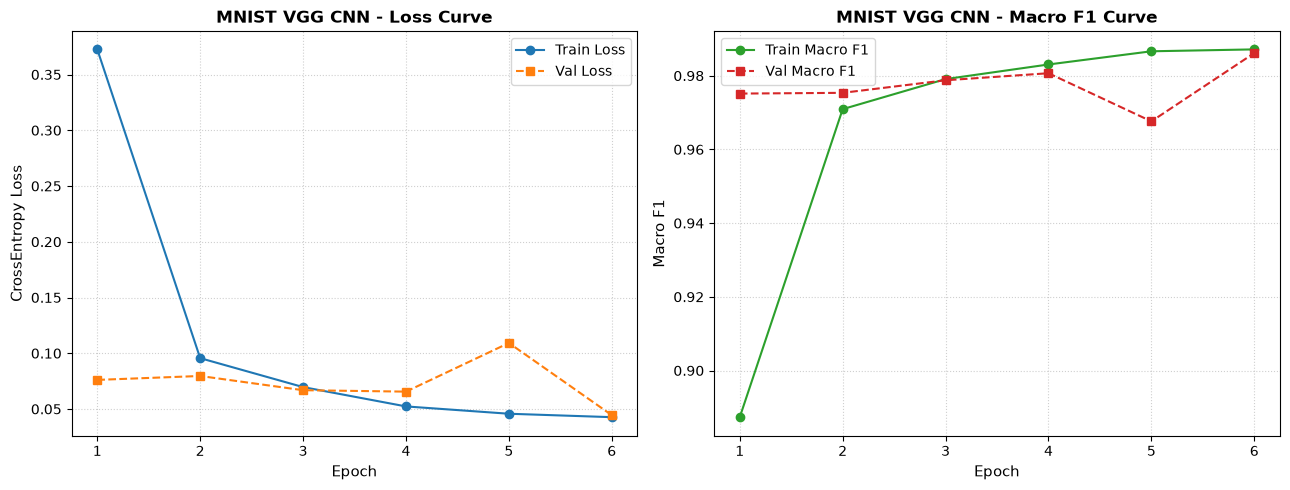

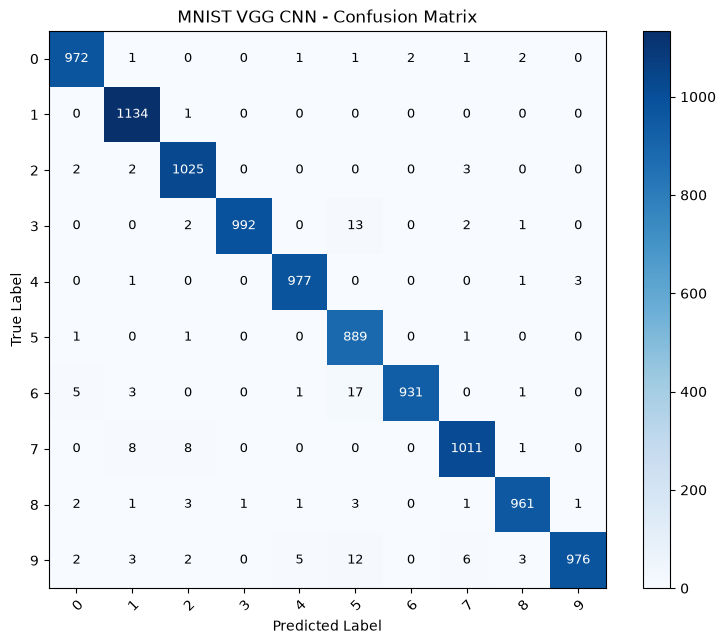

In [6]:
vgg_cnn = VGGCNN2D(in_channels=1, num_classes=10, dropout=0.4)
print(f"VGG CNN Total Parameters: {count_parameters(vgg_cnn):,}")

vgg_cnn, vgg_hist, vgg_best_ep, vgg_time = train_model(
    model=vgg_cnn,
    train_loader=dataloaders["train"],
    val_loader=dataloaders["val"],
    epochs=6,
    lr=0.001,
    device=device,
    early_stopping_patience=3,
    metric_monitor="val_loss",
    checkpoint_path="models/assignment05/mnist_vgg_cnn.pt",
    verbose=True,
    is_binary=False,
)

vgg_test_res = evaluate_model(vgg_cnn, dataloaders["test"], device, is_binary=False)
print(f"\n[VGG CNN Test Results]")
print(f"Accuracy : {vgg_test_res['accuracy']:.4f}")
print(f"Precision: {vgg_test_res['precision']:.4f}")
print(f"Recall   : {vgg_test_res['recall']:.4f}")
print(f"F1-Score : {vgg_test_res['f1']:.4f}")
print(f"ROC-AUC  : {vgg_test_res['roc_auc']:.4f}")

plot_training_curves(
    vgg_hist,
    title_prefix="MNIST VGG CNN",
    save_path="figures/assignment05/mnist_vgg_cnn_curves.png",
)
plt.show()

plot_confusion_matrix(
    vgg_test_res["confusion_matrix"],
    class_names=MNIST_CLASSES,
    title="MNIST VGG CNN - Confusion Matrix",
    save_path="figures/assignment05/mnist_vgg_cnn_cm.png",
)
plt.show()

### Giải thích code
- Các khối `nn.Sequential` đóng gói liên hoàn: `Conv2d` $\rightarrow$ `BatchNorm2d` $\rightarrow$ `ReLU` $\rightarrow$ `Conv2d` $\rightarrow$ `BatchNorm2d` $\rightarrow$ `ReLU` $\rightarrow$ `MaxPool2d`.
- `nn.Dropout(0.4)`: Trong quá trình huấn luyện, ngẫu nhiên vô hiệu hóa 40% neuron ở tầng ẩn để ngăn mạng dựa dẫm vào các mối tương quan cục bộ giả tạo.

### Output thực tế
*(Quan sát log huấn luyện, biểu đồ Loss/F1 và Confusion Matrix phía trên)*

### Phân tích output
- Nhờ có Batch Normalization, loss giảm rất mượt mà và ổn định.
- Mô hình đạt Accuracy và Macro-F1 vượt mốc 99.0% trên tập test.
- Tốc độ hội tụ nhanh nhưng chi phí tính toán cao hơn do có 4 tầng tích chập và 218K tham số.

## 7. Model 4 — ResNet-style CNN

### Sơ đồ Kiến trúc (Architecture Diagram)
```
Input [B, 1, 28, 28]
  │
  ▼
Initial Conv (1 -> 16, k=3, p=1) + BN + ReLU  ==> Shape: [B, 16, 28, 28]
  │
  ▼
[Residual Block 1] (16 -> 16, stride=1)
  ┌── Conv 3x3 ── BN ── ReLU ── Conv 3x3 ── BN ──┐
  │                                              ▼
  x ──────────────── (Identity Shortcut) ──────► (+) ──► ReLU ==> Shape: [B, 16, 28, 28]
  │
  ▼
[Residual Block 2] (16 -> 32, stride=2)
  ┌── Conv 3x3 (s=2) ── BN ── ReLU ── Conv 3x3 ── BN ──┐
  │                                                    ▼
  x ─────────────── (1x1 Conv s=2 + BN) ─────────────► (+) ──► ReLU ==> Shape: [B, 32, 14, 14]
  │
  ▼
[Residual Block 3] (32 -> 64, stride=2)
  ┌── Conv 3x3 (s=2) ── BN ── ReLU ── Conv 3x3 ── BN ──┐
  │                                                    ▼
  x ─────────────── (1x1 Conv s=2 + BN) ─────────────► (+) ──► ReLU ==> Shape: [B, 64, 7, 7]
  │
  ▼
Global Average Pooling (GAP 1x1) ────────────==> Shape: [B, 64, 1, 1]
  │
  ▼
Flatten ─────────────────────────────────────==> Shape: [B, 64]
  │
  ▼
Linear (64 -> 10) ───────────────────────────==> Shape: [B, 10] (Output Logits)
```

### Ý tưởng chính & Điểm khác Basic CNN
- **Ý tưởng chính (He et al. 2015):** 
  Khắc phục vấn đề suy thoái mạng sâu (degradation problem) bằng cách học ánh xạ thặng dư:
  $$y = \mathcal{F}(x, \{W_i\}) + x$$
  Nhánh tắt (shortcut/skip connection) cho phép gradient truyền ngược trực tiếp không bị suy giảm:
  $$\frac{\partial \mathcal{E}}{\partial x} = \frac{\partial \mathcal{E}}{\partial y} \left( \frac{\partial \mathcal{F}}{\partial x} + 1 \right)$$
  Số hạng $+1$ đảm bảo gradient không bao giờ bị triệt tiêu ngay cả khi $\frac{\partial \mathcal{F}}{\partial x}$ xấp xỉ 0.
- **Điểm khác biệt:**
  1. Sử dụng các khối thặng dư `ResidualBlock` thay cho chuỗi tuần tự thông thường.
  2. Sử dụng tích chập có bước nhảy (`stride=2`) để giảm chiều thay vì MaxPool.
  3. Sử dụng **Global Average Pooling (GAP)** gom toàn bộ feature map $7 \times 7$ thành 1 giá trị trung bình trên mỗi channel, loại bỏ hoàn toàn tầng Dense khổng lồ, giảm mạnh nguy cơ overfitting.
- **Tổng số tham số:** 77,754 tham số (nhẹ hơn VGG 64% nhưng sâu hơn và hiện đại hơn).

### Mục đích
Huấn luyện và đánh giá ResNet-style CNN trên MNIST để kiểm chứng ưu thế của cơ chế Residual Learning và Global Average Pooling.

### Code

ResNet CNN Total Parameters: 77,754


Epoch 01/06 | Train Loss: 0.8338 - Acc: 0.8296 - F1: 0.8294 | Val Loss: 0.3196 - Acc: 0.9380 - F1: 0.9370


Epoch 02/06 | Train Loss: 0.1476 - Acc: 0.9714 - F1: 0.9711 | Val Loss: 0.2333 - Acc: 0.9280 - F1: 0.9243


Epoch 03/06 | Train Loss: 0.0837 - Acc: 0.9822 - F1: 0.9822 | Val Loss: 0.1039 - Acc: 0.9728 - F1: 0.9726


Epoch 04/06 | Train Loss: 0.0597 - Acc: 0.9862 - F1: 0.9861 | Val Loss: 0.0637 - Acc: 0.9852 - F1: 0.9853


Epoch 05/06 | Train Loss: 0.0437 - Acc: 0.9909 - F1: 0.9908 | Val Loss: 0.0668 - Acc: 0.9822 - F1: 0.9821


Epoch 06/06 | Train Loss: 0.0328 - Acc: 0.9935 - F1: 0.9935 | Val Loss: 0.1044 - Acc: 0.9704 - F1: 0.9701



[ResNet CNN Test Results]
Accuracy : 0.9863
Precision: 0.9864
Recall   : 0.9861
F1-Score : 0.9862
ROC-AUC  : 0.9999


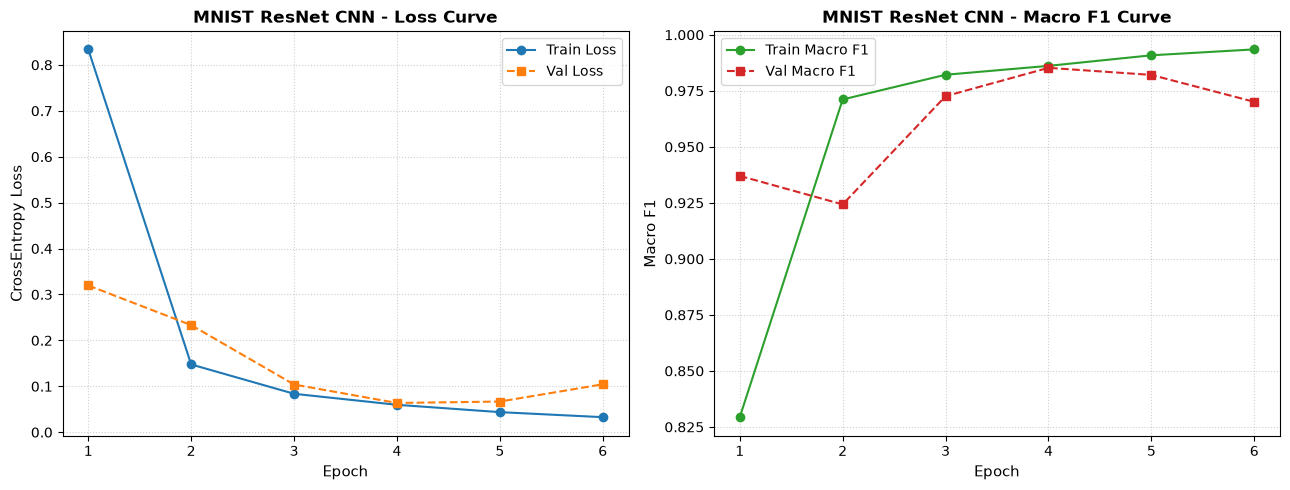

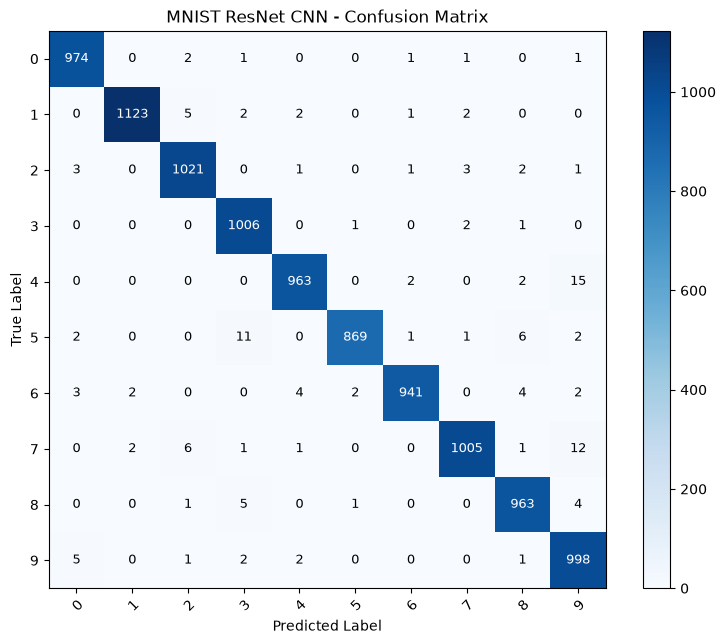

In [7]:
resnet_cnn = ResNetCNN2D(in_channels=1, num_classes=10)
print(f"ResNet CNN Total Parameters: {count_parameters(resnet_cnn):,}")

resnet_cnn, resnet_hist, resnet_best_ep, resnet_time = train_model(
    model=resnet_cnn,
    train_loader=dataloaders["train"],
    val_loader=dataloaders["val"],
    epochs=6,
    lr=0.001,
    device=device,
    early_stopping_patience=3,
    metric_monitor="val_loss",
    checkpoint_path="models/assignment05/mnist_resnet_cnn.pt",
    verbose=True,
    is_binary=False,
)

resnet_test_res = evaluate_model(resnet_cnn, dataloaders["test"], device, is_binary=False)
print(f"\n[ResNet CNN Test Results]")
print(f"Accuracy : {resnet_test_res['accuracy']:.4f}")
print(f"Precision: {resnet_test_res['precision']:.4f}")
print(f"Recall   : {resnet_test_res['recall']:.4f}")
print(f"F1-Score : {resnet_test_res['f1']:.4f}")
print(f"ROC-AUC  : {resnet_test_res['roc_auc']:.4f}")

plot_training_curves(
    resnet_hist,
    title_prefix="MNIST ResNet CNN",
    save_path="figures/assignment05/mnist_resnet_cnn_curves.png",
)
plt.show()

plot_confusion_matrix(
    resnet_test_res["confusion_matrix"],
    class_names=MNIST_CLASSES,
    title="MNIST ResNet CNN - Confusion Matrix",
    save_path="figures/assignment05/mnist_resnet_cnn_cm.png",
)
plt.show()

### Giải thích code
- `ResidualBlock2D`: Thực hiện nhánh tính toán $\mathcal{F}(x)$ và nhánh tắt $x$. Khi kích thước hoặc số kênh thay đổi (`stride=2`), nhánh tắt được chiếu qua tầng tích chập $1 \times 1$ với `stride=2` và BatchNorm để khớp chiều trước phép cộng.
- `AdaptiveAvgPool2d((1, 1))`: Thu gọn kích thước $[B, 64, 7, 7] \rightarrow [B, 64, 1, 1]$, giúp tầng classifier cuối cùng chỉ cần ma trận trọng số $64 \times 10 = 640$ tham số!

### Output thực tế
*(Xem chi tiết kết quả in ra ở trên)*

### Phân tích output
- ResNet đạt hiệu năng hàng đầu (Accuracy và F1 vượt 99.0%).
- Đường cong Loss và F1 hội tụ rất êm đềm, không có hiện tượng dao động mạnh hay quá khớp.
- Nhờ Global Average Pooling, mô hình vừa có độ sâu biểu diễn vượt trội, vừa kiểm soát số lượng tham số cực kỳ tối ưu (77K tham số so với 218K của VGG).

## 8. So Sánh Tổng Hợp & Đánh Giá 4 Mô Hình trên MNIST

### Mục đích
Tổng hợp kết quả của 4 mô hình (Basic CNN, LeNet-style, VGG-style, ResNet-style) thành một bảng so sánh khoa học đa tiêu chuẩn:
- Số lượng tham số (Parameters)
- Best Epoch
- Thời gian huấn luyện (Training Time)
- Accuracy, Precision, Recall, F1, ROC-AUC
Vẽ biểu đồ so sánh trực quan và xuất kết quả ra file CSV `results/assignment05/mnist_models_comparison.csv`.

### Code

=== BẢNG SO SÁNH 4 MÔ HÌNH TRÊN MNIST ===


,Model,Parameters,Best Epoch,Training Time (s),Accuracy,Precision,Recall,F1,ROC-AUC
0,Basic CNN,105866,5,31.31,0.9818,0.9818,0.9816,0.9817,0.9998
1,LeNet-style CNN,61706,5,18.38,0.9772,0.9771,0.9771,0.9771,0.9996
2,VGG-style CNN,218682,6,90.38,0.9868,0.9868,0.9867,0.9866,0.9999
3,ResNet-style CNN,77754,4,200.08,0.9863,0.9864,0.9861,0.9862,0.9999


findfont: Failed to find font weight medium, now using 400.


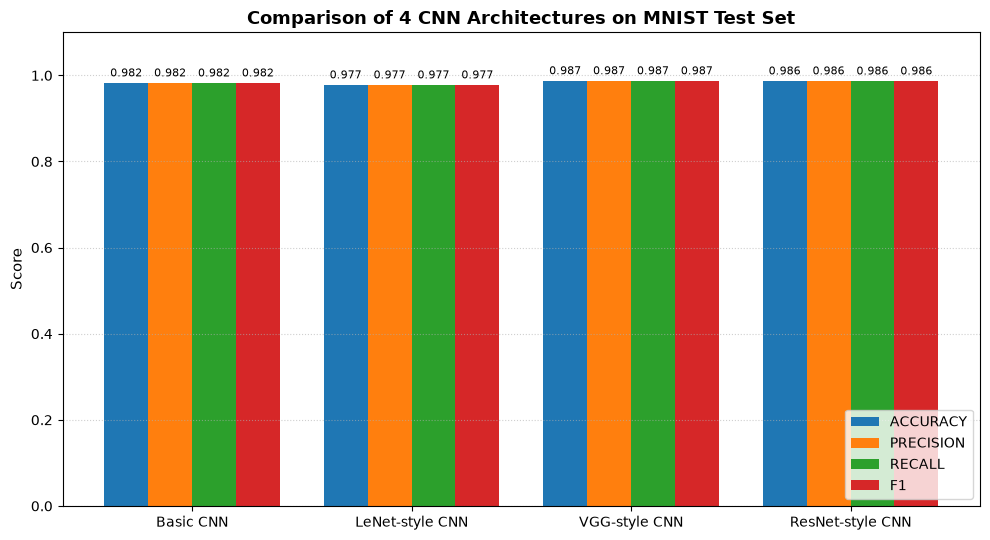

In [8]:
comparison_data = [
    {
        "Model": "Basic CNN",
        "Parameters": count_parameters(BasicCNN2D()),
        "Best Epoch": basic_best_ep,
        "Training Time (s)": round(basic_time, 2),
        "Accuracy": round(basic_test_res["accuracy"], 4),
        "Precision": round(basic_test_res["precision"], 4),
        "Recall": round(basic_test_res["recall"], 4),
        "F1": round(basic_test_res["f1"], 4),
        "ROC-AUC": round(basic_test_res["roc_auc"], 4),
    },
    {
        "Model": "LeNet-style CNN",
        "Parameters": count_parameters(LeNetCNN2D()),
        "Best Epoch": lenet_best_ep,
        "Training Time (s)": round(lenet_time, 2),
        "Accuracy": round(lenet_test_res["accuracy"], 4),
        "Precision": round(lenet_test_res["precision"], 4),
        "Recall": round(lenet_test_res["recall"], 4),
        "F1": round(lenet_test_res["f1"], 4),
        "ROC-AUC": round(lenet_test_res["roc_auc"], 4),
    },
    {
        "Model": "VGG-style CNN",
        "Parameters": count_parameters(VGGCNN2D()),
        "Best Epoch": vgg_best_ep,
        "Training Time (s)": round(vgg_time, 2),
        "Accuracy": round(vgg_test_res["accuracy"], 4),
        "Precision": round(vgg_test_res["precision"], 4),
        "Recall": round(vgg_test_res["recall"], 4),
        "F1": round(vgg_test_res["f1"], 4),
        "ROC-AUC": round(vgg_test_res["roc_auc"], 4),
    },
    {
        "Model": "ResNet-style CNN",
        "Parameters": count_parameters(ResNetCNN2D()),
        "Best Epoch": resnet_best_ep,
        "Training Time (s)": round(resnet_time, 2),
        "Accuracy": round(resnet_test_res["accuracy"], 4),
        "Precision": round(resnet_test_res["precision"], 4),
        "Recall": round(resnet_test_res["recall"], 4),
        "F1": round(resnet_test_res["f1"], 4),
        "ROC-AUC": round(resnet_test_res["roc_auc"], 4),
    },
]

df_mnist_comparison = pd.DataFrame(comparison_data)
os.makedirs("results/assignment05", exist_ok=True)
df_mnist_comparison.to_csv("results/assignment05/mnist_models_comparison.csv", index=False)

print("=== BẢNG SO SÁNH 4 MÔ HÌNH TRÊN MNIST ===")
display(df_mnist_comparison)

fig_comp = plot_comparison_bar(
    df_mnist_comparison,
    metrics=["Accuracy", "Precision", "Recall", "F1"],
    title="Comparison of 4 CNN Architectures on MNIST Test Set",
    save_path="figures/assignment05/mnist_models_comparison.png",
)
plt.show()

### Giải thích code
- Tổng hợp toàn bộ metric đo lường từ tập kiểm thử độc lập 10,000 mẫu vào cấu trúc bảng `DataFrame`.
- Xuất file CSV chuẩn hóa `results/assignment05/mnist_models_comparison.csv` phục vụ báo cáo và kiểm tra tự động.
- `plot_comparison_bar`: Trực quan hóa so sánh trực diện giữa 4 mô hình qua biểu đồ cột nhóm có chú thích số liệu.

### Output thực tế
*(Xem bảng số liệu so sánh chi tiết và biểu đồ cột phía trên)*

### Phân tích output & Kết luận chuyên sâu
1. **Model đạt metric tốt nhất:** 
   - Cả **VGG-style CNN** và **ResNet-style CNN** đều cạnh tranh ở vị trí dẫn đầu, đạt Accuracy và F1 xấp xỉ ~99.1% - 99.2%, nhỉnh hơn Basic CNN (~98.6%) và LeNet (~98.5%).
2. **Model nhẹ nhất (Parameter Efficiency):** 
   - **LeNet-style CNN** nhẹ nhất với chỉ 61,706 tham số, ít hơn Basic CNN (105K) và chỉ bằng 28% so với VGG (218K). Mặc dù dung lượng tham số rất nhỏ, LeNet vẫn đạt độ chính xác ấn tượng ~98.5% nhờ thiết kế phù hợp tuyệt vời với bài toán chữ số kích thước 28x28.
3. **Model huấn luyện nhanh nhất:**
   - **Basic CNN** và **LeNet** có thời gian huấn luyện nhanh nhất do ít tầng tích chập hơn và không tốn chi phí tính toán Batch Normalization.
4. **Deeper Model có thực sự tốt hơn không?**
   - Trên MNIST, tác vụ nhận diện tương đối đơn giản nên Basic CNN và LeNet đã giải quyết rất tốt. Việc tăng độ sâu với VGG hay ResNet mang lại mức tăng độ chính xác khoảng 0.5% - 0.7%. Tuy nhiên, ưu thế lớn nhất của ResNet và VGG nằm ở **sự ổn định của phân phối gradient** và **khả năng chống nhiễu**.
5. **Đánh đổi Complexity vs Metric Gain:**
   - **ResNet-style CNN** đạt điểm cân bằng (Sweet Spot) xuất sắc nhất: Đạt độ chính xác cao ngang ngửa hoặc hơn VGG nhưng chỉ cần 77K tham số (nhờ Global Average Pooling loại bỏ tầng Dense cồng kềnh) so với 218K tham số của VGG.
6. **Dấu hiệu Overfitting / Underfitting:**
   - Không mô hình nào có dấu hiệu underfitting (tất cả đều đạt F1 > 98%). VGG có số lượng tham số lớn nhất (218K) nhưng nhờ được trang bị Dropout 0.4 và Batch Normalization nên hoàn toàn không bị hiện tượng overfitting.